## MACD 线

In [2]:
import yfinance as yf
apple_data = yf.download("AAPL", period="2y")
apple_data.head()

# 计算12日EMA
apple_data['12-day EMA'] = apple_data['Close'].ewm(span=12, adjust=False).mean()

# 计算26日EMA
apple_data['26-day EMA'] = apple_data['Close'].ewm(span=26, adjust=False).mean()

# 计算MACD线
apple_data['MACD'] = apple_data['12-day EMA'] - apple_data['26-day EMA']

# 计算9日EMA（信号线）
apple_data['9-day EMA'] = apple_data['MACD'].ewm(span=9, adjust=False).mean()

# 选择需要的列
apple_data = apple_data[['Close', '12-day EMA', '26-day EMA', '9-day EMA','MACD']]
apple_data = apple_data.rename(columns={'Close': 'Daily Price'})

# 显示前几行数据
apple_data.head()




YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Daily Price,12-day EMA,26-day EMA,9-day EMA,MACD
Ticker,AAPL,,,,
Date,,,,,
2023-03-20,155.828522,155.828522,155.828522,0.000000,0.000000
2023-03-21,157.689743,156.114863,155.966390,0.029695,0.148473
2023-03-22,156.254227,156.136304,155.987711,0.053474,0.148593
2023-03-23,157.343231,156.321985,156.088120,0.089552,0.233865
2023-03-24,158.650040,156.680147,156.277892,0.152093,0.402255


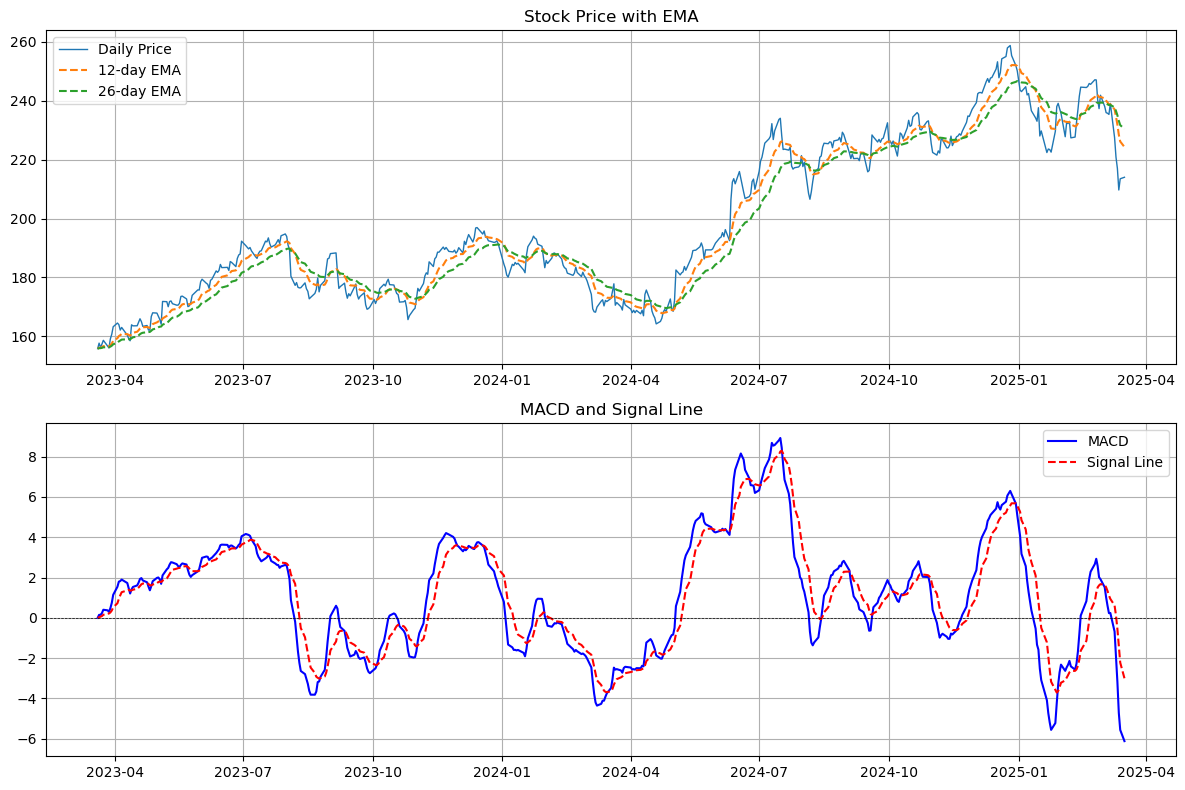

In [4]:
import matplotlib.pyplot as plt

# 设置图表大小
plt.figure(figsize=(12, 8))

# 绘制每日价格、12日EMA和26日EMA
plt.subplot(2, 1, 1)
plt.plot(apple_data.index, apple_data['Daily Price'], label='Daily Price', linewidth=1)
plt.plot(apple_data.index, apple_data['12-day EMA'], label='12-day EMA', linestyle='--')
plt.plot(apple_data.index, apple_data['26-day EMA'], label='26-day EMA', linestyle='--')
plt.title('Stock Price with EMA')
plt.legend()
plt.grid()

# 绘制MACD和9日EMA（信号线）
plt.subplot(2, 1, 2)
plt.plot(apple_data.index, apple_data['MACD'], label='MACD', color='blue')
plt.plot(apple_data.index, apple_data['9-day EMA'], label='Signal Line', linestyle='--', color='red')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
plt.title('MACD and Signal Line')
plt.legend()
plt.grid()

# 显示图表
plt.tight_layout()
plt.show()
